In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("final.csv")
df = df.set_index("Datetime")
df.head()

,Global_active_power_mean,Global_active_power_max,Global_active_power_min,Global_active_power_std,Voltage_mean,Voltage_max,Voltage_min,Voltage_std,Global_intensity_mean,Global_intensity_max,...,is_weekend,lag_1,lag_24,lag_168,roll_mean_6h,roll_std_6h,roll_mean_24h,roll_std_24h,roll_mean_168h,roll_std_168h
Datetime,,,,,,,,,,,,,,,,,,,,,
2006-12-23 17:00:00,5.429683,7.164,2.984,1.192589,233.644167,236.25,231.17,1.311882,23.360000,30.4,...,1,4.326733,1.496800,4.188278,3.607728,0.539234,2.931298,0.983724,1.762654,1.143968
2006-12-23 18:00:00,3.879400,5.270,1.666,0.886704,238.000500,240.59,235.57,1.222337,16.363333,22.4,...,1,5.429683,2.686967,3.598283,3.986175,0.861707,3.095168,1.059062,1.770044,1.163571
2006-12-23 19:00:00,4.117833,5.392,2.036,0.831345,238.729333,242.24,235.69,1.477832,17.300000,22.8,...,1,3.879400,3.938167,3.400233,4.144608,0.700778,3.144853,1.067020,1.771717,1.166414
2006-12-23 20:00:00,4.181400,6.230,2.366,0.850218,238.518833,242.02,236.01,1.235284,17.596667,26.2,...,1,4.117833,3.536067,3.268567,4.263197,0.604431,3.152339,1.073439,1.775988,1.173705
2006-12-23 21:00:00,3.288433,5.352,1.390,1.035213,238.594667,241.65,234.89,1.450798,13.893333,22.8,...,1,4.181400,4.451267,3.056467,4.333769,0.556460,3.179228,1.091401,1.781422,1.182734


In [3]:
y_col = "Global_active_power_mean"
df["pred_persistence"] = df[y_col].shift(1)
df["pred_yesterday"] = df[y_col].shift(24)
df["pred_lastweek"] = df[y_col].shift(168)
eval_df = df.dropna(subset=[
    "pred_persistence",
    "pred_yesterday",
    "pred_lastweek"
])


In [4]:
y_true = eval_df[y_col]

results = {}

for name in ["pred_persistence", "pred_yesterday", "pred_lastweek"]:
    y_pred = eval_df[name]

    mse = mean_squared_error(y_true, y_pred)

    results[name] = {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

pd.DataFrame(results).T

,MAE,RMSE,R2
pred_persistence,0.432525,0.670721,0.424658
pred_yesterday,0.630134,0.937308,-0.123587
pred_lastweek,0.624100,0.924940,-0.094129


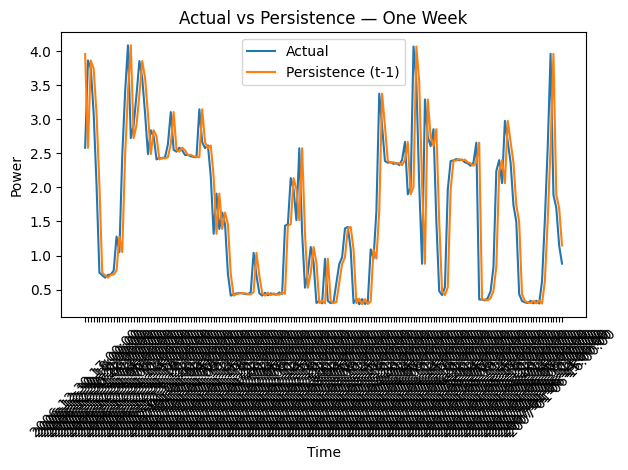

In [5]:
import matplotlib.pyplot as plt

# pick a continuous 1-week window (7 days * 24 hours)
start_idx = 0
window = 168

plot_df = eval_df.iloc[start_idx:start_idx + window]

plt.figure()
plt.plot(plot_df.index, plot_df[y_col], label="Actual")
plt.plot(plot_df.index, plot_df["pred_persistence"], label="Persistence (t-1)")

plt.title("Actual vs Persistence — One Week")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
